# Gráficos de séries temporais do Banco Central do Brasil

Este notebook busca séries temporais da API do Banco Central do Brasil (SGS) e faz gráficos diversos.


In [5]:
%pip install python-bcb

Note: you may need to restart the kernel to use updated packages.


In [6]:
# Carregamento das bibliotecas NumPy e Pandas
import numpy  as np
import pandas as pd

# Carregamento da API do Banco Central do Brasil
from bcb import sgs

# Carregamento do recurso plotly.graph_objects da biblioteca Plotly
import matplotlib.pyplot as plt

In [7]:
# Dicionário de séries temporais mensais de indicadores macroeconômicos
SeriesMensaisMacro = {
    # Atividade econômica
    'PIB mensal':4385,       # PIB em dólares US$ (milhões)
    'IBC-BR':24363,       # Índice de Atividade Econômica, do BCB
    
    # Taxas de juros
    'SELIC':4390,         # Taxa SELIC
    'CDI':4391,           # Taxa CDI
    
    # Índices de inflação
    'IPCA':433            # Índice Nacional de Preços ao Consumidor - Amplo, do IBGE
}

In [8]:
# Obtenção de dados das séries do dicionário, via API
BCBdadosMacro = sgs.get(SeriesMensaisMacro)

In [9]:
# Exibição dos últimos 12 meses das séries escolhidas
BCBdadosMacro.tail(12)

,PIB mensal,IBC-BR,SELIC,CDI,IPCA
Date,,,,,
2025-09-01,200038.0,109.59513,1.22,1.22,0.48
2025-10-01,205622.0,110.16346,1.28,1.28,0.09
2025-11-01,202739.0,106.90236,1.05,1.05,0.18
2025-12-01,198721.0,107.17649,1.22,1.22,0.33
2026-01-01,192348.0,102.36456,1.16,1.16,0.33
2026-02-01,201926.0,106.82125,1.00,1.00,0.70
2026-03-01,223909.0,117.80890,1.21,1.21,0.88
2026-04-01,229361.0,113.99365,1.09,1.09,0.67
2026-05-01,228141.0,109.52993,1.07,1.07,0.58


<Axes: xlabel='Date'>

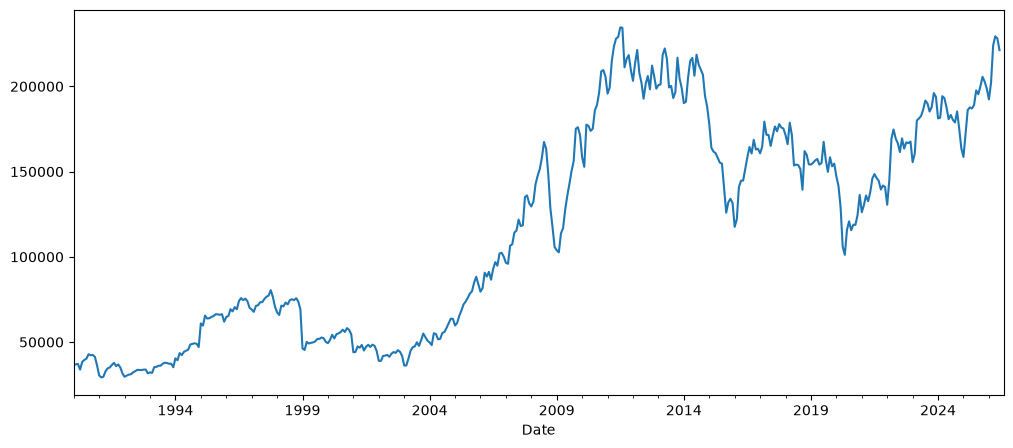

In [10]:
# Gráfico do PIC mensal, a partir de 1990
BCBdadosMacro['PIB mensal'][BCBdadosMacro.index >= '1990-01-01'].plot(figsize = (12,5))

In [11]:
# Gravação da série do PIB mensal em formato CSV
SerieMensalDF = pd.DataFrame()
SerieMensalDF.index = BCBdadosMacro['PIB mensal'].index
SerieMensalDF.index.rename('Data', inplace = True)
SerieMensalDF['PIB'] = BCBdadosMacro['PIB mensal']
SerieMensalDF.dropna(inplace = True)
SerieMensalDF.to_csv('PIBmensal.csv')

<Axes: xlabel='Date'>

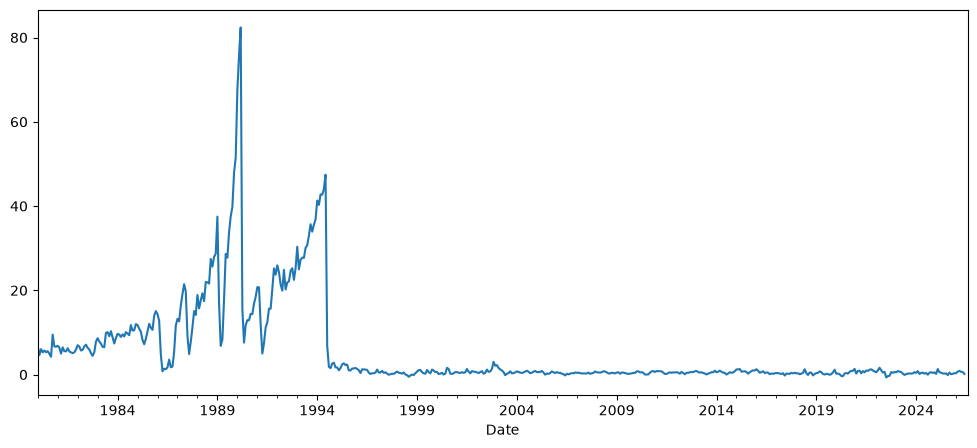

In [12]:
# Gráfico do IPCA mensal
BCBdadosMacro['IPCA'].plot(figsize = (12,5))

<Axes: xlabel='Date'>

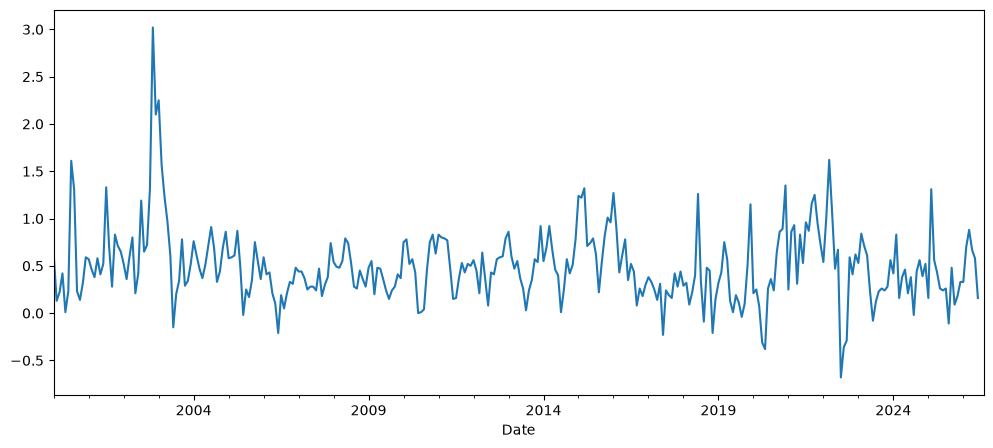

In [13]:
# Gráfico do IPCA mensal, a partir de 2000
BCBdadosMacro['IPCA'][BCBdadosMacro.index >= '2000-01-01'].plot(figsize = (12,5))

In [14]:
# Gravação da série do IPCA mensal em formato CSV
SerieMensalDF = pd.DataFrame()
SerieMensalDF.index = BCBdadosMacro['IPCA'].index
SerieMensalDF.index.rename('Data', inplace = True)
SerieMensalDF['IPCA'] = BCBdadosMacro['IPCA']
SerieMensalDF.dropna(inplace = True)
SerieMensalDF.to_csv('IPCA.csv')

<Axes: xlabel='Date'>

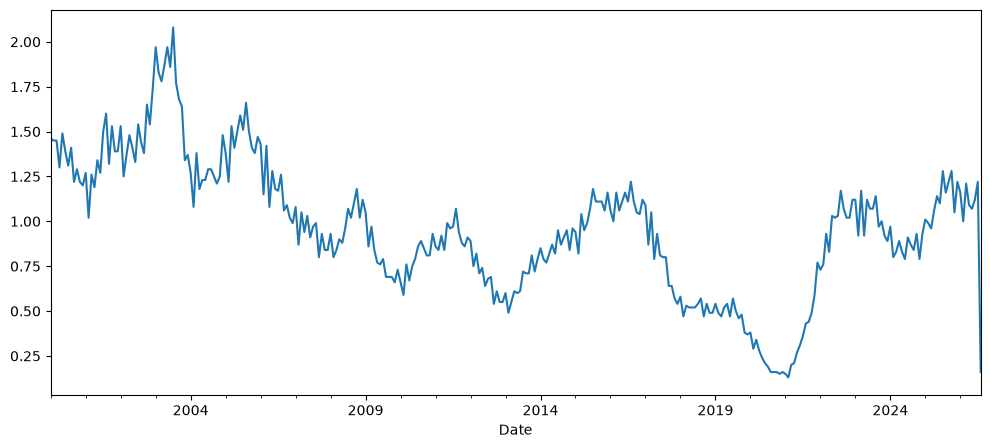

In [15]:
# Gráfico da taxa SELIC mensal, a partir de 2000
BCBdadosMacro['SELIC'][BCBdadosMacro.index >= '2000-01-01'].plot(figsize = (12,5))

In [16]:
# Gravação da série da SELIC mensal em formato CSV
SerieMensalDF = pd.DataFrame()
SerieMensalDF.index = BCBdadosMacro['SELIC'].index
SerieMensalDF.index.rename('Data', inplace = True)
SerieMensalDF['SELIC'] = BCBdadosMacro['SELIC']
SerieMensalDF.dropna(inplace = True)
SerieMensalDF.to_csv('SELIC.csv')

<Axes: xlabel='Date'>

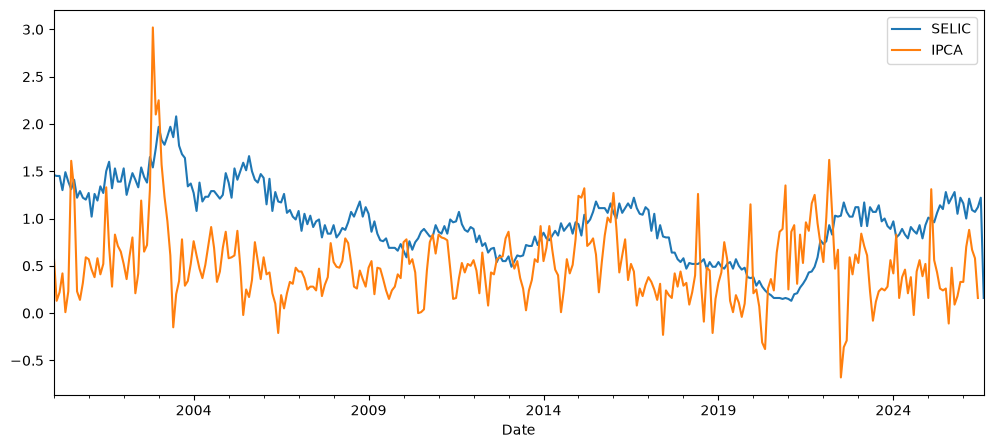

In [17]:
# Gráfico comparativo entre SELIC e IPCA mensais
BCBdadosMacro[['SELIC','IPCA']][BCBdadosMacro.index >= '2000-01-01'].plot(figsize = (12,5))